# Loan Analysis

## Goal of this Program
1. Find any null values
2. Fill them with default values / ignore them
3. Normalize the data with hot encoding
4. Find Corelation Matrix
5. Using the Corelation Matrix select the Features
6. Using the Features find the Linear Regreation


In [1]:
!pip install kagglehub
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install jinja2

zsh:1: /Users/walruii/Documents/repos/data_analytics/loan_analyse/.venv/bin/pip: bad interpreter: /Users/walruii/Documents/repos/software_lab/loan_analyse/.venv/bin/python: no such file or directory
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [kagglehub]/8 [kagglehub]
zsh:1: /Users/walruii/Documents/repos/data_analytics/loan_analyse/.venv/bin/pip: bad interpreter: /Users/walruii/Documents/repos/software_lab/loan_analyse/.venv/bin/python: no such file or directory
zsh:1: /Users/walruii/Documents/repos/data_analytics/loan_analyse/.venv/bin/pip: bad interpreter: /Users/walruii/Documents/repos/software_lab/loan_analyse/.venv/bin/python: no such file or directory
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 2.4 MB/s  0:00:04eta 0:00:01
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached six-1.17.0-p

In [ ]:
# Imports
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


/Users/walruii/Documents/repos/data_analytics/loan_analyse/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Download latest version
path = kagglehub.dataset_download("nikhil1e9/loan-default")
file_path = os.path.join(path, 'Loan_default.csv')

# Checking Data
df = pd.read_csv(file_path)
df.head(10)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
5,A9S62RQ7US,25,90298,90448,720,18,2,22.72,24,0.10,High School,Unemployed,Single,Yes,No,Business,Yes,1
6,H8GXPAOS71,38,111188,177025,429,80,1,19.11,12,0.16,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0
7,0HGZQKJ36W,56,126802,155511,531,67,4,8.15,60,0.43,PhD,Full-time,Married,No,No,Home,Yes,0
8,1R0N3LGNRJ,36,42053,92357,827,83,1,23.94,48,0.20,Bachelor's,Self-employed,Divorced,Yes,No,Education,No,1
9,CM9L1GTT2P,40,132784,228510,480,114,4,9.09,48,0.33,High School,Self-employed,Married,Yes,No,Other,Yes,0


In [10]:
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing_df[missing_df['Missing Count'] > 0])

,Missing Count,Missing Percentage (%)


In [11]:
# Create a copy to preserve the original dataframe
df_encoded = df.copy()

# 1. Binary Mapping (Yes/No -> 1/0)
binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})

# 2. Ordinal Encoding for Education (inherent order)
education_map = {
    'High School': 0,
    'Bachelor\'s': 1,
    'Master\'s': 2,
    'PhD': 3
}
df_encoded['Education'] = df_encoded['Education'].map(education_map)

# 3. One-Hot Encoding for Nominal Categories (no implicit order)
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['EmploymentType', 'MaritalStatus', 'LoanPurpose'],
    drop_first=True,  # Avoids multicollinearity (dummy variable trap)
    dtype=int
)

# 4. Drop non-predictive identifier colum

if 'LoanID' in df_encoded.columns:
    df_encoded.drop(columns=['LoanID'], inplace=True)

df_encoded.head(10)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,...,Default,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,0,0,0,0,0,0,0,0,0,1
1,69,50432,124440,458,15,1,4.81,60,0.68,2,...,0,0,0,0,1,0,0,0,0,1
2,46,84208,129188,451,26,3,21.17,24,0.31,2,...,1,0,0,1,0,0,0,0,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,0,0,0,1,0,1,0,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,1,...,0,0,0,1,0,0,0,0,0,0
5,25,90298,90448,720,18,2,22.72,24,0.10,0,...,1,0,0,1,0,1,1,0,0,0
6,38,111188,177025,429,80,1,19.11,12,0.16,1,...,0,0,0,1,0,1,0,0,1,0
7,56,126802,155511,531,67,4,8.15,60,0.43,3,...,0,0,0,0,1,0,0,0,1,0
8,36,42053,92357,827,83,1,23.94,48,0.20,1,...,1,0,1,0,0,0,0,1,0,0
9,40,132784,228510,480,114,4,9.09,48,0.33,0,...,0,0,1,0,1,0,0,0,0,1


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,HasMortgage,HasDependents,HasCoSigner,Default,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
Age,1.00000,-0.00124,-0.00221,-0.00055,-0.00034,-0.00089,-0.00113,0.00026,-0.00469,-0.00085,0.00003,0.00071,-0.00292,-0.16778,-0.00266,-0.00008,0.00162,0.00189,-0.00284,-0.00310,-0.00230,-0.00047,0.00429
Income,-0.00124,1.00000,-0.00087,-0.00143,0.00267,-0.00202,-0.00230,-0.00100,0.00021,0.00068,-0.00094,-0.00157,-0.00352,-0.09912,-0.00163,-0.00078,-0.00336,-0.00082,0.00096,0.00512,-0.00361,-0.00125,-0.00039
LoanAmount,-0.00221,-0.00087,1.00000,0.00126,0.00282,0.00079,-0.00229,0.00254,0.00112,0.00254,-0.00080,0.00014,-0.00185,0.08666,-0.00204,-0.00116,0.00408,-0.00328,0.00097,-0.00309,0.00047,0.00031,0.00036
CreditScore,-0.00055,-0.00143,0.00126,1.00000,0.00061,0.00002,0.00044,0.00113,-0.00104,-0.00080,0.00173,-0.00302,-0.00275,-0.03417,-0.00062,0.00151,0.00221,0.00011,-0.00284,-0.00064,-0.00331,0.00251,0.00045
MonthsEmployed,-0.00034,0.00267,0.00282,0.00061,1.00000,0.00127,0.00010,-0.00117,0.00176,-0.00115,0.00021,0.00145,0.00105,-0.09737,0.00136,0.00068,-0.00042,0.00106,-0.00061,0.00152,0.00116,-0.00403,-0.00021
NumCreditLines,-0.00089,-0.00202,0.00079,0.00002,0.00127,1.00000,-0.00030,-0.00023,-0.00059,0.00153,-0.00174,-0.00190,0.00211,0.02833,0.00017,0.00075,-0.00037,0.00073,-0.00094,0.00099,0.00204,0.00037,-0.00124
InterestRate,-0.00113,-0.00230,-0.00229,0.00044,0.00010,-0.00030,1.00000,0.00089,0.00058,0.00342,-0.00042,-0.00024,-0.00399,0.13127,0.00028,-0.00102,0.00104,-0.00147,-0.00366,-0.00103,0.00149,0.00258,-0.00113
LoanTerm,0.00026,-0.00100,0.00254,0.00113,-0.00117,-0.00023,0.00089,1.00000,0.00227,-0.00142,0.00178,0.00242,-0.00117,0.00054,0.00051,-0.00275,0.00233,-0.00009,-0.00085,-0.00303,0.00094,-0.00032,0.00305
DTIRatio,-0.00469,0.00021,0.00112,-0.00104,0.00176,-0.00059,0.00058,0.00227,1.00000,0.00195,0.00023,0.00149,0.00037,0.01924,0.00089,-0.00034,-0.00057,-0.00037,0.00407,0.00048,0.00251,-0.00167,-0.00350
Education,-0.00085,0.00068,0.00254,-0.00080,-0.00115,0.00153,0.00342,-0.00142,0.00195,1.00000,0.00196,0.00006,0.00169,-0.02828,0.00083,0.00014,-0.00007,0.00017,-0.00142,-0.00019,-0.00035,-0.00002,-0.00156


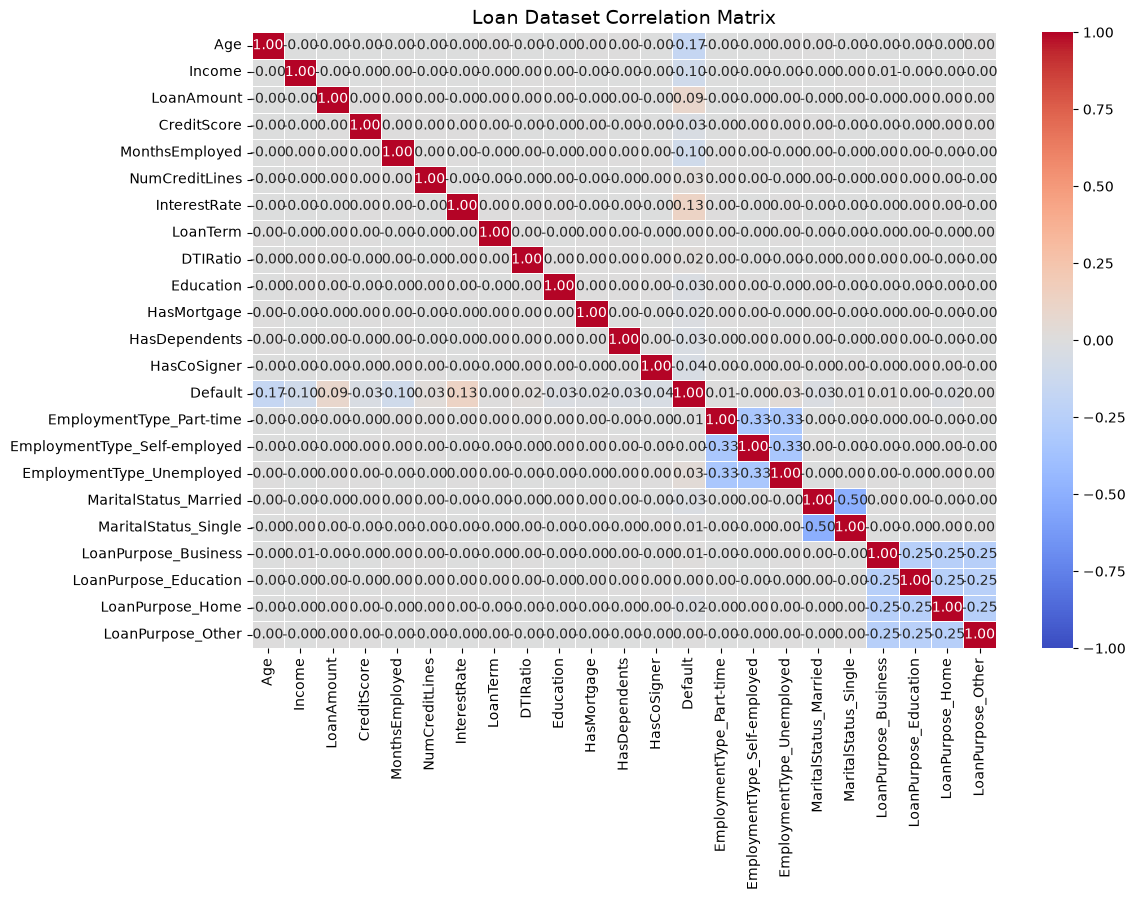

In [13]:
corr_matrix = df_encoded.corr()

# 2. Display the matrix as a styled DataFrame (color-coded numbers)
display(corr_matrix.style.background_gradient(cmap='coolwarm', axis=None).format("{:.5f}"))

# 3. Plot a clean visual heatmap of the matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show values in cells
    fmt=".2f",           # Round values to 2 decimal places
    cmap='coolwarm',     # Red = Positive correlation, Blue = Negative correlation
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Loan Dataset Correlation Matrix", fontsize=14)
plt.show()

In [14]:
# Extract target correlation and sort by absolute strength
target_corr = df_encoded.corr()['Default'].drop('Default')
target_corr_abs = target_corr.abs().sort_values(ascending=False)

# Display top correlated features
top_features_summary = pd.DataFrame({
    'Correlation': target_corr[target_corr_abs.index],
    'Absolute Correlation': target_corr_abs
})

print("Top features related to Loan Default:")
display(top_features_summary)

Top features related to Loan Default:


,Correlation,Absolute Correlation
Age,-0.167783,0.167783
InterestRate,0.131273,0.131273
Income,-0.099119,0.099119
MonthsEmployed,-0.097374,0.097374
LoanAmount,0.086659,0.086659
HasCoSigner,-0.039109,0.039109
EmploymentType_Unemployed,0.034957,0.034957
HasDependents,-0.034678,0.034678
CreditScore,-0.034166,0.034166
NumCreditLines,0.028330,0.028330


In [43]:
# Select features based on a threshold (e.g., |correlation| >= 0.03)
threshold = 0.02
selected_features = top_features_summary[top_features_summary['Absolute Correlation'] >= threshold].index.tolist()

# Define X (features) and y (target)
X = df_encoded[selected_features]
y = df_encoded['Default']  # Replace with your target column name

print(f"Selected {len(selected_features)} features for training:")
print(selected_features)

Selected 14 features for training:
['Age', 'InterestRate', 'Income', 'MonthsEmployed', 'LoanAmount', 'HasCoSigner', 'EmploymentType_Unemployed', 'HasDependents', 'CreditScore', 'NumCreditLines', 'Education', 'MaritalStatus_Married', 'HasMortgage', 'LoanPurpose_Home']


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
from sklearn.linear_model import LinearRegression

# Initialize and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[-0. , 0.01,-0. ,...,-0.02,-0.01,-0.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['Age','InterestRate','Income',...,'MaritalStatus_Married','HasMortgage', 'LoanPurpose_Home']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3241
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [46]:
y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Mean Squared Error (MSE): 0.0936
R-squared (R2 Score): 0.0837


In [48]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

display(coefficients)

,Feature,Coefficient
6,EmploymentType_Unemployed,2.638935e-02
9,NumCreditLines,8.073960e-03
1,InterestRate,6.243797e-03
4,LoanAmount,3.878537e-07
2,Income,-8.212230e-07
8,CreditScore,-6.984764e-05
3,MonthsEmployed,-8.848679e-04
0,Age,-3.579455e-03
10,Education,-7.787530e-03
12,HasMortgage,-1.374620e-02


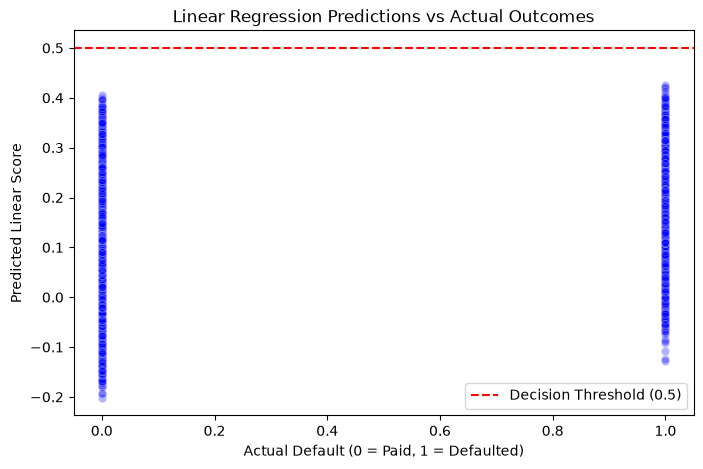

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# Scatter plot of actual vs predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='blue')

# Draw a threshold line (e.g., 0.5) to separate predicted Default vs Non-Default
plt.axhline(y=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')

plt.xlabel("Actual Default (0 = Paid, 1 = Defaulted)")
plt.ylabel("Predicted Linear Score")
plt.title("Linear Regression Predictions vs Actual Outcomes")
plt.legend()
plt.show()

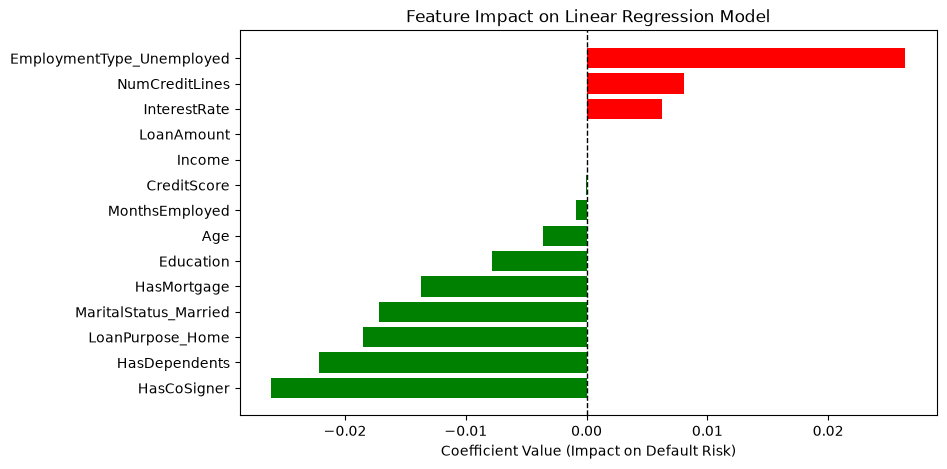

In [50]:
# Create a DataFrame for feature coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=['green' if x < 0 else 'red' for x in coef_df['Coefficient']])

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlabel("Coefficient Value (Impact on Default Risk)")
plt.title("Feature Impact on Linear Regression Model")
plt.show()